In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("E:/Machine Learning/Dataset/Iris.csv")

In [3]:
df

,Unnamed: 0,sepalLength,sepalWidth,petalLength,petalWidth,species
0,0,5.1,3.5,1.4,0.2,setosa
1,1,4.9,3.0,1.4,0.2,setosa
2,2,4.7,3.2,1.3,0.2,setosa
3,3,4.6,3.1,1.5,0.2,setosa
4,4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...,...
145,145,6.7,3.0,5.2,2.3,virginica
146,146,6.3,2.5,5.0,1.9,virginica
147,147,6.5,3.0,5.2,2.0,virginica
148,148,6.2,3.4,5.4,2.3,virginica


In [4]:
df = df.iloc[:,1:]

In [5]:
df

,sepalLength,sepalWidth,petalLength,petalWidth,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()


In [8]:
df['species'] = encoder.fit_transform(df['species'])

In [9]:
df.head()

,sepalLength,sepalWidth,petalLength,petalWidth,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df = df[df['species'] != 0][["sepalLength", "petalLength",'species']]

In [11]:
df

,sepalLength,petalLength,species
50,7.0,4.7,1
51,6.4,4.5,1
52,6.9,4.9,1
53,5.5,4.0,1
54,6.5,4.6,1
...,...,...,...
145,6.7,5.2,2
146,6.3,5.0,2
147,6.5,5.2,2
148,6.2,5.4,2


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

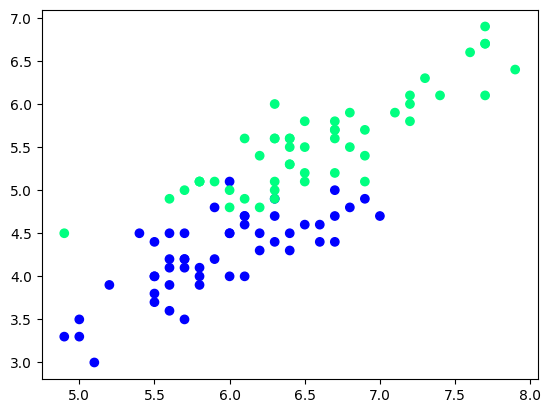

In [13]:
plt.scatter(df["sepalLength"],df["petalLength"],c = df['species'], cmap = "winter")

In [14]:
df_train = df.iloc[:60, :].sample(10)

In [15]:
df_train

,sepalLength,petalLength,species
80,5.5,3.8,1
70,5.9,4.8,1
75,6.6,4.4,1
104,6.5,5.8,2
103,6.3,5.6,2
82,5.8,3.9,1
77,6.7,5.0,1
51,6.4,4.5,1
57,4.9,3.3,1
73,6.1,4.7,1


In [16]:
#Taking only 10 rows for training

df = df.sample(100)
df_train = df.iloc[:60, :].sample(10)
df_val = df.iloc[60:80, :].sample(5)
df_test = df.iloc[80:, :].sample(5)

In [17]:
df_train

,sepalLength,petalLength,species
91,6.1,4.6,1
68,6.2,4.5,1
86,6.7,4.7,1
111,6.4,5.3,2
121,5.6,4.9,2
146,6.3,5.0,2
71,6.1,4.0,1
117,7.7,6.7,2
58,6.6,4.6,1
110,6.5,5.1,2


In [18]:
df_val

,sepalLength,petalLength,species
103,6.3,5.6,2
82,5.8,3.9,1
78,6.0,4.5,1
70,5.9,4.8,1
51,6.4,4.5,1


In [19]:
df_test

,sepalLength,petalLength,species
120,6.9,5.7,2
133,6.3,5.1,2
97,6.2,4.3,1
132,6.4,5.6,2
76,6.8,4.8,1


In [20]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values 

In [21]:
y_test


array([2, 1, 1, 1, 1])

## Case 1 - Bagging

In [22]:
# Data for tree 1

df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:,0:2]
Y = df_bag.iloc[:, -1]

In [23]:
df_bag

,sepalLength,petalLength,species
146,6.3,5.0,2
146,6.3,5.0,2
121,5.6,4.9,2
111,6.4,5.3,2
68,6.2,4.5,1
146,6.3,5.0,2
68,6.2,4.5,1
58,6.6,4.6,1


In [25]:
# install compatible packages to avoid "No module named 'matplotlib.backends.registry'"
# (restart the kernel after installation if the modules were previously imported)
%pip install "matplotlib>=3.6" mlxtend


from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

Note: you may need to restart the kernel to use updated packages.


In [27]:
dt_bag1 = DecisionTreeClassifier()

In [ ]:
def evaluate(clf, X, y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf = clf, legend = 2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))



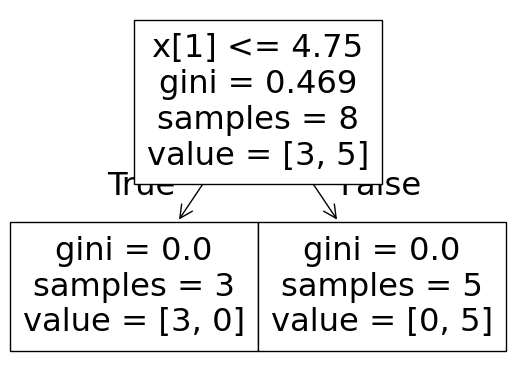

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


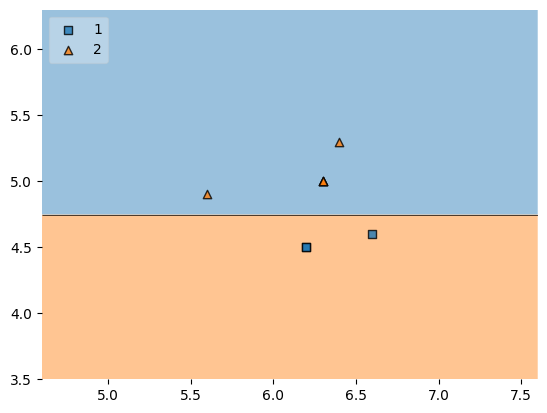

In [36]:
evaluate(dt_bag1,X,Y)

In [45]:
# Data for tree 2
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:,0:2]
Y = df_bag.iloc[:, -1]

In [47]:
df_bag

,sepalLength,petalLength,species
117,7.7,6.7,2
86,6.7,4.7,1
111,6.4,5.3,2
86,6.7,4.7,1
111,6.4,5.3,2
68,6.2,4.5,1
58,6.6,4.6,1
91,6.1,4.6,1


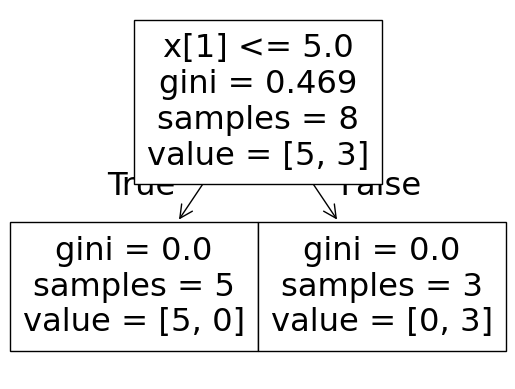

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


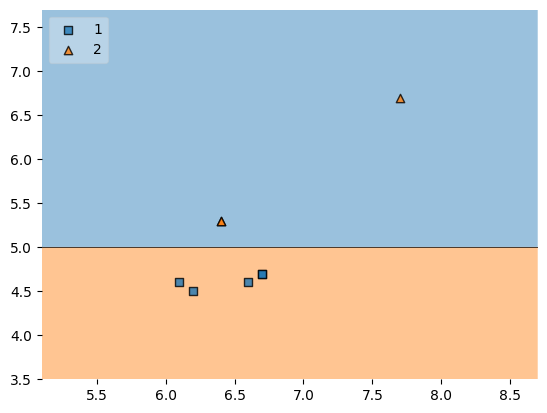

In [48]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, X,Y)

In [49]:
# data for tree 3
df_bag = df_train.sample(8, replace = True)
X = df_bag.iloc[:,0:2]
Y = df_bag.iloc[:, -1]

In [50]:
df_bag

,sepalLength,petalLength,species
121,5.6,4.9,2
121,5.6,4.9,2
117,7.7,6.7,2
71,6.1,4.0,1
58,6.6,4.6,1
58,6.6,4.6,1
111,6.4,5.3,2
86,6.7,4.7,1


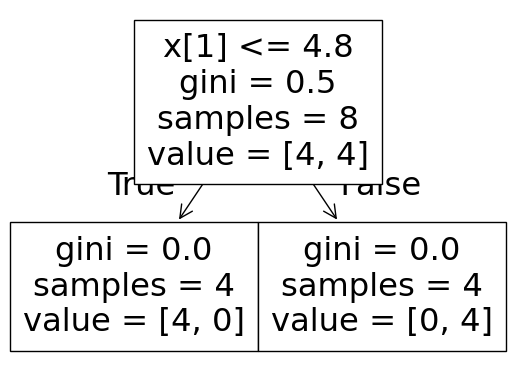

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


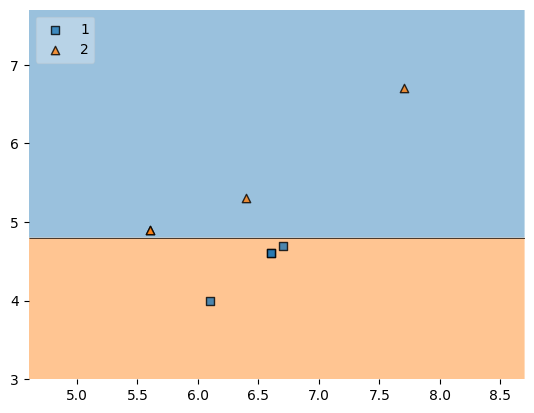

In [51]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3, X,Y)

## Predict

In [40]:
df_test

,sepalLength,petalLength,species
120,6.9,5.7,2
133,6.3,5.1,2
97,6.2,4.3,1
132,6.4,5.6,2
76,6.8,4.8,1


In [52]:
print("Predictor 1", dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2", dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3", dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [1]
Predictor 3 [2]


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Pasting

In [56]:
# Row sampling without replacement 
df_train

,sepalLength,petalLength,species
91,6.1,4.6,1
68,6.2,4.5,1
86,6.7,4.7,1
111,6.4,5.3,2
121,5.6,4.9,2
146,6.3,5.0,2
71,6.1,4.0,1
117,7.7,6.7,2
58,6.6,4.6,1
110,6.5,5.1,2


In [57]:
df_train.sample(8)

,sepalLength,petalLength,species
68,6.2,4.5,1
117,7.7,6.7,2
58,6.6,4.6,1
111,6.4,5.3,2
91,6.1,4.6,1
146,6.3,5.0,2
86,6.7,4.7,1
71,6.1,4.0,1


## Random Subspaces

In [58]:
df1 = pd.read_csv('E:/Machine Learning/Dataset/Iris.csv')

In [60]:
df1 = df1.sample(10)

In [61]:
df1

,Unnamed: 0,sepalLength,sepalWidth,petalLength,petalWidth,species
77,77,6.7,3.0,5.0,1.7,versicolor
129,129,7.2,3.0,5.8,1.6,virginica
14,14,5.8,4.0,1.2,0.2,setosa
48,48,5.3,3.7,1.5,0.2,setosa
42,42,4.4,3.2,1.3,0.2,setosa
84,84,5.4,3.0,4.5,1.5,versicolor
40,40,5.0,3.5,1.3,0.3,setosa
0,0,5.1,3.5,1.4,0.2,setosa
45,45,4.8,3.0,1.4,0.3,setosa
36,36,5.5,3.5,1.3,0.2,setosa


In [70]:
df1.sample(2, replace = True, axis = 1)

,petalWidth,species
77,1.7,versicolor
129,1.6,virginica
14,0.2,setosa
48,0.2,setosa
42,0.2,setosa
84,1.5,versicolor
40,0.3,setosa
0,0.2,setosa
45,0.3,setosa
36,0.2,setosa


## Random Patches

In [71]:
df1

,Unnamed: 0,sepalLength,sepalWidth,petalLength,petalWidth,species
77,77,6.7,3.0,5.0,1.7,versicolor
129,129,7.2,3.0,5.8,1.6,virginica
14,14,5.8,4.0,1.2,0.2,setosa
48,48,5.3,3.7,1.5,0.2,setosa
42,42,4.4,3.2,1.3,0.2,setosa
84,84,5.4,3.0,4.5,1.5,versicolor
40,40,5.0,3.5,1.3,0.3,setosa
0,0,5.1,3.5,1.4,0.2,setosa
45,45,4.8,3.0,1.4,0.3,setosa
36,36,5.5,3.5,1.3,0.2,setosa


In [73]:
df1.sample(8, replace = True).sample(3, replace=True, axis = 1)

,sepalWidth,sepalLength,petalWidth
40,3.5,5.0,0.3
40,3.5,5.0,0.3
0,3.5,5.1,0.2
40,3.5,5.0,0.3
84,3.0,5.4,1.5
77,3.0,6.7,1.7
84,3.0,5.4,1.5
0,3.5,5.1,0.2
